In [ ]:
import logging
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import chi2_contingency
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedGroupKFold

import eda_utils as eu
from ml_config import PipelineConfig
from ml_evaluation import compute_metrics, precision_at_k
from ml_features import PanelFeatureEngineer
from ml_models import build_model_trainer
from ml_preprocess import (
    CategoricalEncoder,
    DataCleaner,
    detect_duplicate_column_groups,
    identify_volatile_ids,
)
from ml_validation import build_group_cv_splits

warnings.filterwarnings("ignore", category=FutureWarning)
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger("notebook")

PALETTE = {"neg": "#3A7D44", "pos": "#C73E1D", "primary": "#2E86AB", "secondary": "#A23B72", "accent": "#F18F01"}
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette([PALETTE["primary"], PALETTE["secondary"], PALETTE["accent"]])
%matplotlib inline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
DATA_PATH = "train_df.csv"
OUTPUT_DIR = Path("notebook_artifacts")
OUTPUT_DIR.mkdir(exist_ok=True)

config = PipelineConfig(
    data_path=Path(DATA_PATH),
    output_dir=OUTPUT_DIR,
    random_state=RANDOM_STATE,
    catboost_iterations=300,
    lightgbm_n_estimators=300,
    run_shap=False,
)
ID_COL, TARGET_COL = config.id_col, config.target_col
MODELS = ["catboost", "lightgbm"]

print("Configuration loaded.")
print(f"  CV folds: {config.n_splits}")
print(f"  CatBoost iterations: {config.catboost_iterations}")
print(f"  Output: {OUTPUT_DIR.resolve()}")


EDA

So, our data have a connection to user, so, we can use basic train/test split

We have deeply imbalanced dataset, so we will use F1, ROC-AUC, pression and recall as key metrics

We can safily get rid of it.

In [32]:
from scipy.stats import mannwhitneyu

In [36]:
mw_results = []
for col in num_cols:
    g0 = df.loc[df['gb'] == 0, col].dropna()
    g1 = df.loc[df['gb'] == 1, col].dropna()
    
    if len(g0) < 20 or len(g1) < 20:
        continue
        
    try:
        _, p_value = mannwhitneyu(g0, g1, alternative="two-sided")
        mw_results.append({
            "feature":  col,
            "p_value":  p_value,
            "median_0": round(g0.median(), 4),
            "median_1": round(g1.median(), 4),
            "significant": p_value < 0.05, 
        })
    except Exception:
        pass

mw_df = pd.DataFrame(mw_results).sort_values("p_value").reset_index(drop=True)
sig_mw = mw_df[mw_df["significant"]]

print(f"Statistically significant numerical features (p < 0.05): {len(sig_mw)} out of {len(mw_df)}")
display(sig_mw.head(10))

Statistically significant numerical features (p < 0.05): 233 out of 303


,feature,p_value,median_0,median_1,significant
0,num_105,4.972279e-82,-12423.760,-95489.150,True
1,num_197,4.514105e-79,13.000,6.000,True
2,num_43,1.134797e-74,330000.000,1295417.480,True
3,num_132,2.375108e-66,57.000,33.000,True
4,num_134,4.257951e-66,1717.000,996.000,True
5,num_340,4.257951e-66,1721.000,1000.000,True
6,num_276,2.634840e-63,27959.885,126871.460,True
7,num_169,1.210315e-59,17221.735,77870.775,True
8,num_234,1.198603e-58,1385.000,633.000,True
9,num_235,1.672505e-58,46.000,21.000,True


### **Statistical Feature Selection: Mann-Whitney U Test**

* **Methodology:** We performed a two-sided **Mann-Whitney U test** 
* **Key Findings:**
* **233 Significant Features ($p < 0.05$):** Show distinct, non-random distributional shifts between paying (`gb=0`) and defaulting (`gb=1`) clients. These hold strong predictive power.
* **70 Non-Significant Features ($p \ge 0.05$):** Show identical distributions across both groups, meaning they offer zero discriminative value for default risk.


* **Next Step:** Safely **drop the 70 non-significant features** to reduce dimensionality, eliminate statistical noise, and prevent model overfitting.

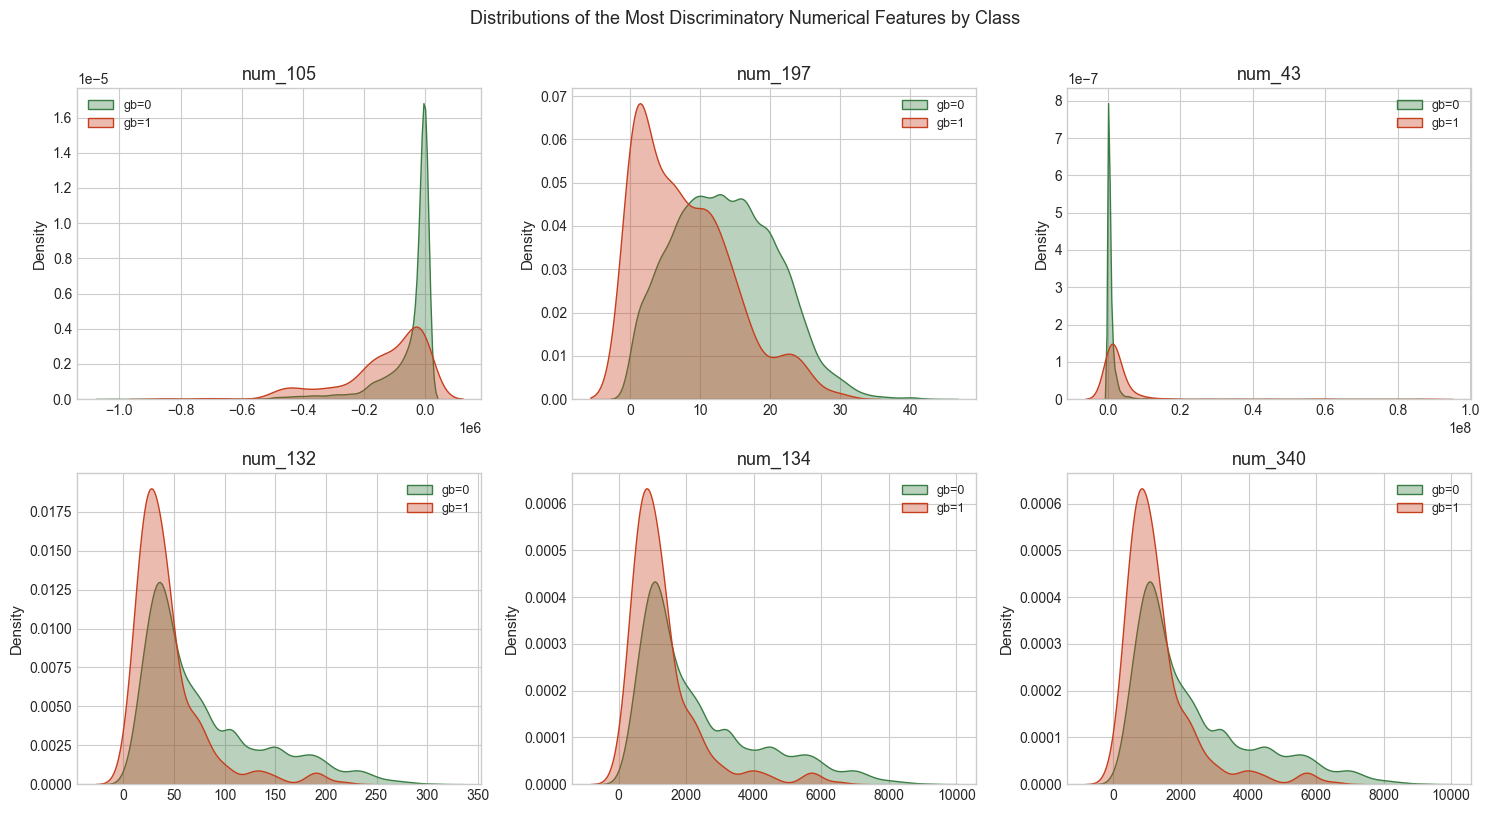

In [43]:
top_features = sig_mw["feature"].head(6).tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, top_features):
    for label, color, name in [(0, PALETTE["neg"], "gb=0"), (1, PALETTE["pos"], "gb=1")]:
        subset = df.loc[df['gb'] == label, col].dropna()
        if len(subset) > 10:
            sns.kdeplot(subset, ax=ax, label=name, color=color, fill=True, alpha=0.35)
    ax.set_title(col)
    ax.legend(fontsize=9)
    ax.set_xlabel("")

fig.suptitle("Distributions of the Most Discriminatory Numerical Features by Class", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


Features with |skew| > 2:          313
Median skewness:                 9.68
Features with >5% IQR outliers:  274


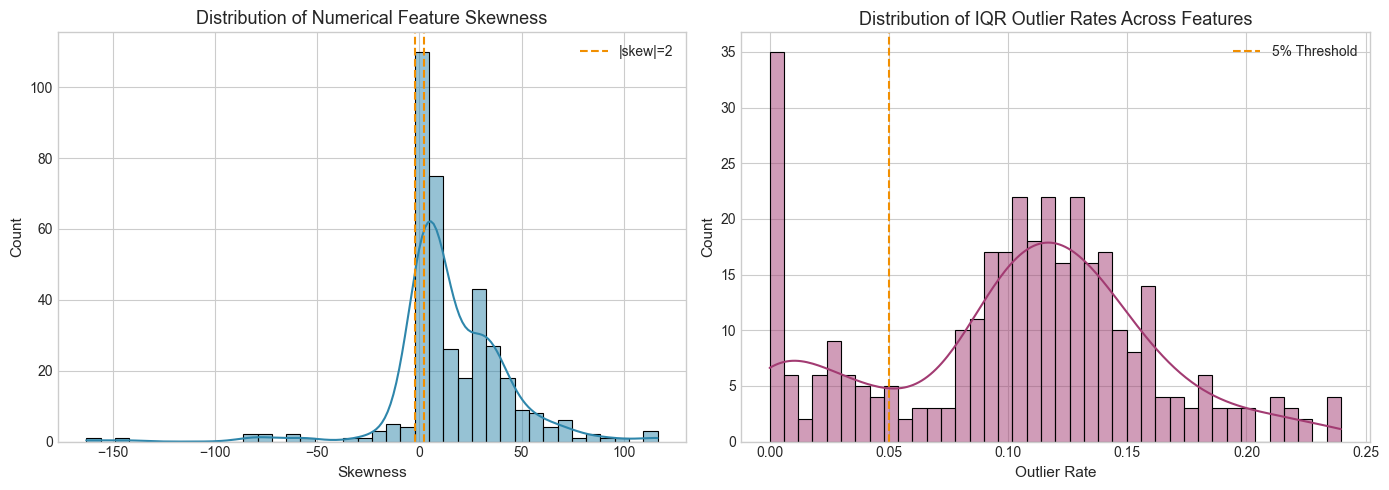

In [46]:
num_df = df[num_cols]

# Compute Skewness
skewness = num_df.apply(lambda s: s.dropna().skew() if s.notna().sum() >= 50 else np.nan)

# Compute IQR outlier rates
outlier_rates = {}
for col in num_cols:
    s = num_df[col].dropna()
    if len(s) < 50:
        continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if iqr > 0:
        outlier_rates[col] = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).mean()
outlier_series = pd.Series(outlier_rates)

# Print Summary Metrics
print(f"Features with |skew| > 2:          {(skewness.abs() > 2).sum()}")
print(f"Median skewness:                 {skewness.median():.2f}")
print(f"Features with >5% IQR outliers:  {(outlier_series > 0.05).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Skewness Distribution
sns.histplot(skewness.dropna(), bins=40, kde=True, color=PALETTE["primary"], ax=axes[0])
axes[0].axvline(2,  color=PALETTE["accent"], ls="--", label="|skew|=2")
axes[0].axvline(-2, color=PALETTE["accent"], ls="--")
axes[0].set_title("Distribution of Numerical Feature Skewness")
axes[0].set_xlabel("Skewness")
axes[0].legend()

# Plot Outlier Rates Distribution
sns.histplot(outlier_series.dropna(), bins=40, kde=True, color=PALETTE["secondary"], ax=axes[1])
axes[1].axvline(0.05, color=PALETTE["accent"], ls="--", label="5% Threshold")
axes[1].set_title("Distribution of IQR Outlier Rates Across Features")
axes[1].set_xlabel("Outlier Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

A median skewness of approximately 9–10 indicates highly skewed feature distributions, 
which is a characteristic pattern commonly observed in financial and banking datasets. 
While tree-based models like CatBoost and LightGBM are inherently robust against both 
scale and extreme asymmetry, linear models are highly sensitive to these data properties. 
Therefore, to ensure stable coefficient estimation for Logistic Regression, we will 
apply a RobustScaler during preprocessing to shield the model from outlier distortion.

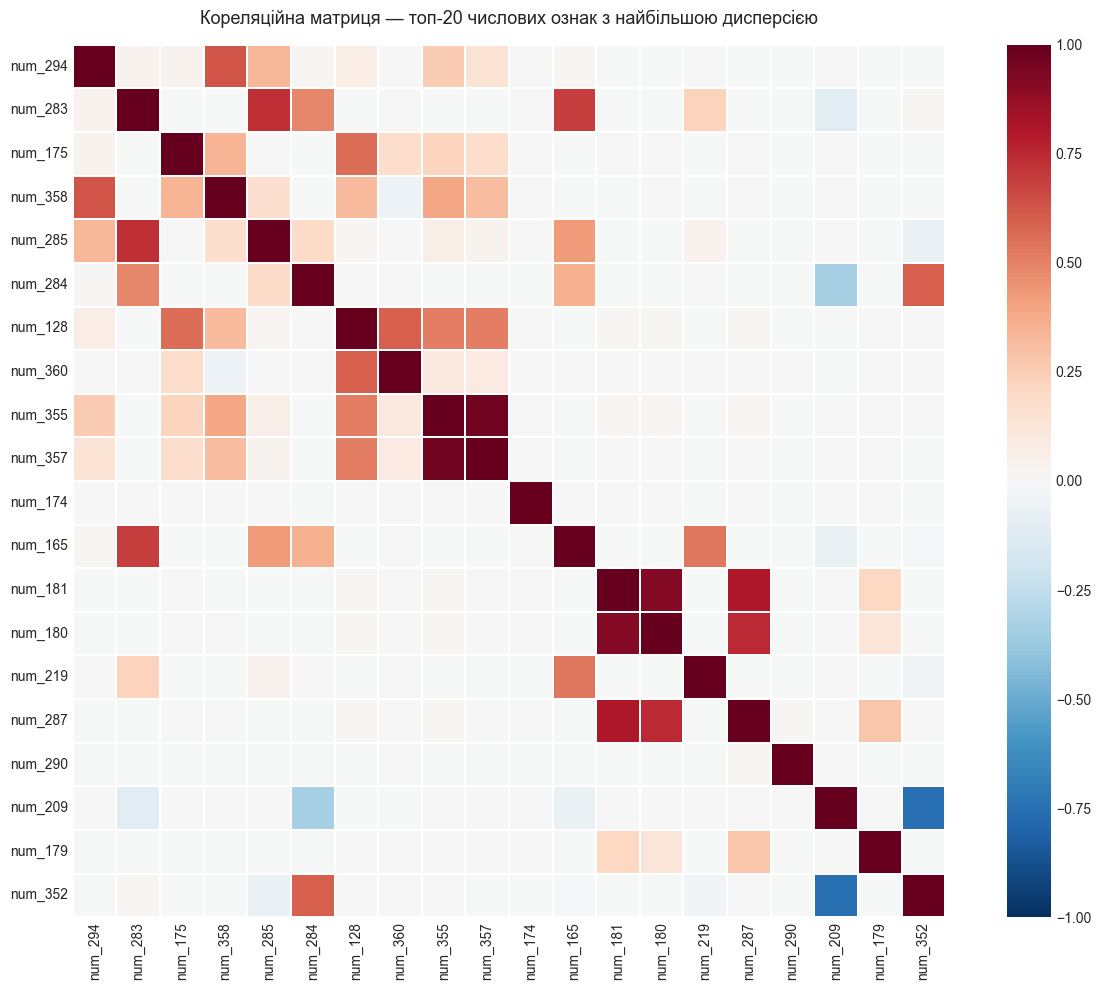

Пар з |r| > 0.95: 1096

Інтерпретація:
  • Велика кількість сильно скорельованих пар вказує на надлишкову інформацію.
  • Для Logistic Regression це критично (мультиколінеарність) — видалимо дублікати.
  • CatBoost/LightGBM більш стійкі до кореляції, але очищення прискорить навчання.



In [47]:
# ─── Кореляційна матриця ────────────────────────────────────────────────────
active_num = [c for c in num_cols if df[c].notna().sum() >= 500]
variances = df[active_num].var().sort_values(ascending=False)
heatmap_cols = variances.head(20).index.tolist()

corr_sub = df[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr_sub,
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    square=True, ax=ax,
    annot=False, linewidths=0.3
)
ax.set_title("Кореляційна матриця — топ-20 числових ознак з найбільшою дисперсією", pad=15)
plt.tight_layout()
plt.show()

# Підрахунок високо-корельованих пар
num_valid = [c for c in num_cols if df[c].notna().sum() >= 50]
corr_full = df[num_valid].corr().abs()
upper = corr_full.where(np.triu(np.ones(corr_full.shape), k=1).astype(bool))
high_corr_pairs = upper.stack().reset_index()
high_corr_pairs.columns = ["a", "b", "r"]
high_corr_pairs = high_corr_pairs[high_corr_pairs["r"] > 0.95]

print(f"Пар з |r| > 0.95: {len(high_corr_pairs)}")
print("""
Інтерпретація:
  • Велика кількість сильно скорельованих пар вказує на надлишкову інформацію.
  • Для Logistic Regression це критично (мультиколінеарність) — видалимо дублікати.
  • CatBoost/LightGBM більш стійкі до кореляції, але очищення прискорить навчання.
""")

тут може бути падродкос XOR, того будемо видялти занчення лише для лоігчтисної регструї, що буникнути колінеарності, проте, для дерев рішень ми це збережемо.

In [53]:
# Рахуємо кількість унікальних значень для кожної категоріальної ознаки
cardinality = df[cat_cols].nunique()

# Виводимо бінарні ознаки (те, що намагався показати правий графік)
binary_feats = cardinality[cardinality == 2].index.tolist()
print(f"Binary features (2 unique values): {len(binary_feats)} features")

# Знаходимо ознаки з високою кардинальністю (те, що ховав лівий графік)
high_card_feats = cardinality[cardinality > 10].sort_values(ascending=False)
print(f"\nHigh-cardinality features (>3 unique values): {len(high_card_feats)}")
print(high_card_feats.head(10))

Binary features (2 unique values): 14 features

High-cardinality features (>3 unique values): 9
cat_98     1461
cat_60     1313
cat_19      630
cat_38      428
cat_124      58
cat_21       42
cat_77       22
cat_97       22
cat_73       19
dtype: int64


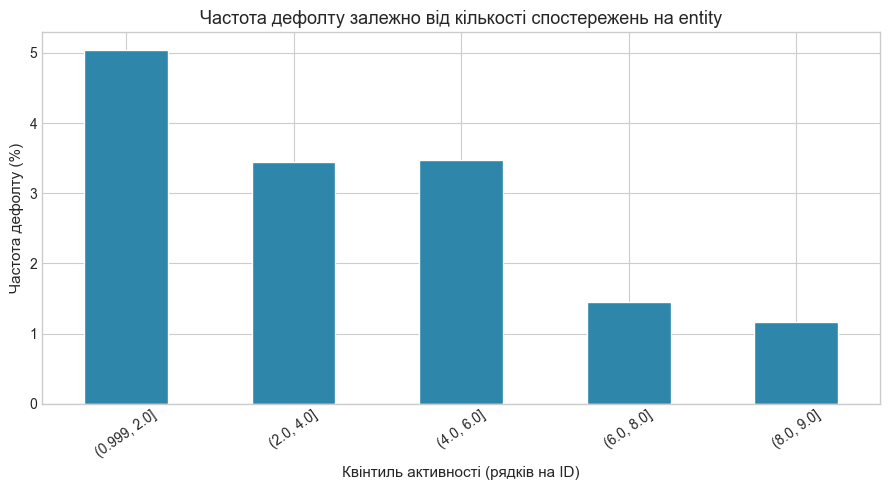


Інтерпретація:
  • Entities з меншою кількістю спостережень частіше дефолтять.
  • Це може бути пов'язано з коротшим вікном спостереження або вищим ризиком нових клієнтів.
  • ВАЖЛИВО: не можна використовувати random train/test split — треба StratifiedGroupKFold по ID!



In [55]:
# ─── Активність entity (rows per ID) vs частота дефолту ────────────────────
id_stats = (
    df.groupby('id')
    .agg(row_count=('gb', "count"), target_mean=('gb', "mean"))
    .reset_index()
)
id_stats["activity_q"] = pd.qcut(id_stats["row_count"], q=5, duplicates="drop")
activity_risk = id_stats.groupby("activity_q", observed=True)["target_mean"].mean().mul(100)

fig, ax = plt.subplots(figsize=(9, 5))
activity_risk.plot(kind="bar", color=PALETTE["primary"], ax=ax, edgecolor="white")
ax.set_ylabel("Частота дефолту (%)")
ax.set_xlabel("Квінтиль активності (рядків на ID)")
ax.set_title("Частота дефолту залежно від кількості спостережень на entity")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

print("""
Інтерпретація:
  • Entities з меншою кількістю спостережень частіше дефолтять.
  • Це може бути пов'язано з коротшим вікном спостереження або вищим ризиком нових клієнтів.
  • ВАЖЛИВО: не можна використовувати random train/test split — треба StratifiedGroupKFold по ID!
""")

There is a clear inverse relationship between an entity's data density (number of historical records per ID) and its default risk. "New" or low-activity entities (1–2 records) exhibit a ~5% default rate, whereas highly active, tenured entities (8–9 records) drop to ~1%.

In [ ]:
empty_cols = [c for c in feature_cols if df[c].isnull().mean() >= 1.0]
df = df.drop(columns=empty_cols)

In [56]:
# 1. Transpose only our feature columns, find duplicates, and get their names
to_drop = df[feature_cols].T.duplicated(keep='first')
duplicate_cols = to_drop[to_drop == True].index.tolist()

# 2. Physically drop them from the DataFrame
df = df.drop(columns=duplicate_cols)

# 3. Update the feature list
feature_cols = [c for c in feature_cols if c not in duplicate_cols]

print(f"  • Successfully dropped {len(duplicate_cols)} exact duplicate columns.")
if len(duplicate_cols) > 0:
    print(f"  • Removed: {duplicate_cols}")

  • Successfully dropped 44 exact duplicate columns.
  • Removed: ['num_111', 'num_152', 'num_19', 'num_23', 'num_242', 'num_248', 'num_250', 'num_258', 'num_266', 'num_267', 'num_269', 'num_270', 'num_312', 'num_330', 'num_331', 'num_338', 'num_342', 'num_365', 'num_372', 'num_375', 'num_379', 'num_380', 'num_392', 'num_405', 'num_406', 'num_409', 'num_411', 'num_412', 'num_57', 'num_66', 'num_68', 'num_69', 'num_71', 'num_83', 'num_92', 'cat_127', 'cat_13', 'cat_30', 'cat_42', 'cat_53', 'cat_66', 'cat_7', 'cat_79', 'cat_86']


In [ ]:
def drop_high_corr(df, num_cols, threshold=0.95, min_valid=50):
    """Видаляємо одну ознаку з кожної пари з |r| > threshold."""
    valid = [c for c in num_cols if df[c].notna().sum() >= min_valid]
    if len(valid) < 2:
        return num_cols
    corr = df[valid].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = upper.stack().reset_index()
    pairs.columns = ["a", "b", "r"]
    pairs = pairs[pairs["r"] > threshold].sort_values("r", ascending=False)
    to_drop = set()
    for _, row in pairs.iterrows():
        a, b = row["a"], row["b"]
        if a not in to_drop and b not in to_drop:
            to_drop.add(b)  # видаляємо другий з пари
    print(f"  • Видалено {len(to_drop)} сильно скорельованих ознак (|r| > {threshold})")
    return [c for c in num_cols if c not in to_drop]

Заюзати це тільки коли дойде до лоігстично хресгреЇ, уджде швидлови вдиляти для дерев рішень

In [ ]:
def chi2_missingness_vs_target(
    df: pd.DataFrame,
    columns: list[str],
    target_col: str,
    min_missing_pct: float = 10.0,
    alpha: float = 0.05,
) -> pd.DataFrame:
    """
    Test whether missingness is associated with the target (chi-square).

    Returns DataFrame with column, p_value, cramers_v.
    """
    results = []
    y = df[target_col]

    for col in columns:
        miss_pct = df[col].isnull().mean() * 100
        if miss_pct < min_missing_pct or miss_pct >= 100:
            continue

        table = pd.crosstab(df[col].isnull(), y)
        if table.shape != (2, 2):
            continue

        chi2, p_value, _, _ = chi2_contingency(table)
        n = table.values.sum()
        cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1))) if n > 0 else 0.0
        results.append({"feature": col, "p_value": p_value, "cramers_v": cramers_v})

    out = pd.DataFrame(results)
    if out.empty:
        return out
    return out.sort_values("p_value").reset_index(drop=True)


In [ ]:

def categorical_cardinality(cat_df: pd.DataFrame) -> pd.Series:
    """Unique value counts per categorical column."""
    return cat_df.nunique().sort_values(ascending=False)


def plot_cardinality_distribution(
    cardinality: pd.Series,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    """Histogram of categorical cardinalities."""
    ax = ax or plt.subplots(figsize=DEFAULT_FIGSIZE)[1]
    sns.histplot(cardinality, bins=30, color=PALETTE["primary"], ax=ax)
    ax.axvline(50, color=PALETTE["accent"], linestyle="--", label="High-cardinality (>50)")
    ax.set_xlabel("Number of unique values")
    ax.set_ylabel("Number of categorical features")
    ax.set_title("Categorical Feature Cardinality Distribution")
    ax.legend()
    return ax


def cramers_v_correlation(cat_series: pd.Series, target: pd.Series) -> float:
    """Cramér's V association between a categorical feature and binary target."""
    table = pd.crosstab(cat_series, target)
    if table.size == 0:
        return 0.0
    chi2, _, _, _ = chi2_contingency(table)
    n = table.values.sum()
    min_dim = min(table.shape) - 1
    if n == 0 or min_dim == 0:
        return 0.0
    return float(np.sqrt(chi2 / (n * min_dim)))

In [ ]:
def target_stability_per_id(
    df: pd.DataFrame,
    id_col: str,
    target_col: str,
) -> tuple[int, int]:
    """Return (total_ids, ids_with_changing_target)."""
    nunique = df.groupby(id_col)[target_col].nunique()
    return len(nunique), int((nunique > 1).sum())
def static_vs_dynamic_features(
    df: pd.DataFrame,
    id_col: str,
    numeric_cols: list[str],
    min_count: int = 500,
    static_threshold: float = 0.05,
) -> pd.DataFrame:
    """
    Classify numeric features as static (constant within ID) vs dynamic.

    variance_ratio = mean(within-id variance) / global variance
    """
    valid = [c for c in numeric_cols if df[c].notna().sum() >= min_count]
    records = []

    for col in valid:
        total_var = df[col].var()
        if total_var == 0 or pd.isna(total_var):
            continue
        within_var = df.groupby(id_col)[col].var().mean()
        ratio = within_var / total_var if pd.notna(within_var) else 0.0
        records.append(
            {
                "feature": col,
                "variance_ratio": ratio,
                "type": "static" if ratio < static_threshold else "dynamic",
            }
        )

    return pd.DataFrame(records)

In [ ]:
"""
Leakage-safe preprocessing: column pruning, MNAR indicators, correlation filtering.
"""

from __future__ import annotations

import logging
from typing import Iterable

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
from sklearn.feature_selection import mutual_info_classif

from eda_utils import detect_duplicate_column_groups, low_variance_columns
from ml_config import PipelineConfig

logger = logging.getLogger(__name__)


def identify_volatile_ids(
    df: pd.DataFrame,
    id_col: str,
    target_col: str,
) -> list:
    """Entity IDs whose target label changes across panel rows."""
    nunique = df.groupby(id_col)[target_col].nunique()
    return nunique[nunique > 1].index.tolist()


def identify_mnar_columns(
    df: pd.DataFrame,
    columns: list[str],
    target_col: str,
    min_missing_pct: float,
    alpha: float,
) -> list[str]:
    """
    Features where missingness is statistically associated with the target.

    Fit only on training data inside each CV fold to avoid leakage.
    """
    mnar_cols: list[str] = []
    y = df[target_col]

    for col in columns:
        miss_pct = df[col].isnull().mean() * 100
        if miss_pct < min_missing_pct or miss_pct >= 100:
            continue

        table = pd.crosstab(df[col].isnull(), y)
        if table.shape != (2, 2):
            continue

        _, p_value, _, _ = chi2_contingency(table)
        if p_value < alpha:
            mnar_cols.append(col)

    return sorted(mnar_cols)


def _mutual_info_scores(
    X: pd.DataFrame,
    y: pd.Series,
    columns: list[str],
    random_state: int,
) -> dict[str, float]:
    """Compute mutual information per column (numeric only for stability)."""
    if not columns:
        return {}

    X_sub = X[columns].copy()
    for col in columns:
        if X_sub[col].dtype == "object" or str(X_sub[col].dtype).startswith("category"):
            X_sub[col] = X_sub[col].astype("category").cat.codes
        X_sub[col] = X_sub[col].fillna(X_sub[col].median())

    mi = mutual_info_classif(
        X_sub.values,
        y.values,
        random_state=random_state,
        discrete_features=False,
    )
    return dict(zip(columns, mi))


def prune_correlated_features(
    df: pd.DataFrame,
    numeric_cols: list[str],
    y: pd.Series,
    threshold: float,
    min_valid: int,
    random_state: int,
) -> list[str]:
    """
    Deterministically drop one feature from each highly correlated pair.

    Keep the feature with higher (MI, variance, name) lexicographic rank.
    """
    valid = [c for c in numeric_cols if df[c].notna().sum() >= min_valid]
    if len(valid) < 2:
        return []

    variances = df[valid].var()
    mi_scores = _mutual_info_scores(df, y, valid, random_state)

    corr = df[valid].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = (
        upper.stack()
        .reset_index()
        .rename(columns={"level_0": "a", "level_1": "b", 0: "corr"})
    )
    pairs = pairs[pairs["corr"] > threshold].sort_values(
        ["corr", "a", "b"], ascending=[False, True, True]
    )

    def rank_key(col: str) -> tuple:
        return (
            mi_scores.get(col, 0.0),
            variances.get(col, 0.0) if pd.notna(variances.get(col)) else 0.0,
            col,
        )

    to_drop: set[str] = set()
    for _, row in pairs.iterrows():
        a, b = row["a"], row["b"]
        if a in to_drop or b in to_drop:
            continue
        keep = max((a, b), key=rank_key)
        drop = b if keep == a else a
        to_drop.add(drop)

    return sorted(to_drop)


class DataCleaner:
    """
    Fit on training fold only: drop empty, duplicate, quasi-constant, correlated.
    Add MNAR missingness indicator columns.
    """

    def __init__(self, config: PipelineConfig):
        self.config = config
        self.columns_to_drop_: list[str] = []
        self.mnar_columns_: list[str] = []
        self.kept_columns_: list[str] = []
        self.indicator_columns_: list[str] = []

    def fit(self, df: pd.DataFrame, y: pd.Series) -> "DataCleaner":
        id_col = self.config.id_col
        target_col = self.config.target_col

        feature_cols = [
            c for c in df.columns if c not in (id_col, target_col)
        ]
        num_cols = [c for c in feature_cols if c.startswith(self.config.num_feature_prefix)]
        cat_cols = [c for c in feature_cols if c.startswith(self.config.cat_feature_prefix)]

        drop_set: set[str] = set()

        # 1) 100% empty
        missing_pct = df[feature_cols].isnull().mean()
        empty = missing_pct[missing_pct >= 1.0].index.tolist()
        drop_set.update(empty)
        logger.info("Dropping %d entirely empty columns", len(empty))

        remaining = [c for c in feature_cols if c not in drop_set]

        # 2) Exact duplicate groups
        dup_groups = detect_duplicate_column_groups(
            df[remaining + [id_col, target_col]],
            remaining,
            min_valid=self.config.min_valid_values,
        )
        n_dup_dropped = 0
        for _canonical, twins in dup_groups.items():
            drop_set.update(twins)
            n_dup_dropped += len(twins)
        logger.info("Dropping %d duplicate columns from %d groups", n_dup_dropped, len(dup_groups))

        remaining = [c for c in remaining if c not in drop_set]

        # 3) Quasi-constant numerics
        low_var = low_variance_columns(
            df[remaining],
            threshold=self.config.low_variance_threshold,
            min_count=self.config.min_valid_values,
        )
        drop_set.update(low_var)
        logger.info("Dropping %d quasi-constant columns", len(low_var))

        remaining = [c for c in remaining if c not in drop_set]
        num_remaining = [c for c in remaining if c in num_cols]

        # 4) MNAR indicators (identify on train; do not drop those columns)
        if self.config.enable_missing_indicators:
            self.mnar_columns_ = identify_mnar_columns(
                df[[target_col] + num_remaining],
                num_remaining,
                target_col,
                self.config.mnar_min_missing_pct,
                self.config.mnar_pvalue_alpha,
            )
            logger.info("MNAR missingness indicators for %d columns", len(self.mnar_columns_))

        # 5) Correlation pruning on numerics
        corr_drop = prune_correlated_features(
            df,
            num_remaining,
            y,
            self.config.corr_threshold,
            self.config.min_valid_values,
            self.config.random_state,
        )
        drop_set.update(corr_drop)
        logger.info("Dropping %d highly correlated columns", len(corr_drop))

        self.columns_to_drop_ = sorted(drop_set)
        self.kept_columns_ = [c for c in feature_cols if c not in self.columns_to_drop_]
        self.indicator_columns_ = [
            f"{c}__is_missing" for c in self.mnar_columns_
        ]
        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        id_col = self.config.id_col
        target_col = self.config.target_col

        out = df[[id_col, target_col] + self.kept_columns_].copy()

        if self.config.enable_missing_indicators and self.mnar_columns_:
            for col in self.mnar_columns_:
                if col in out.columns:
                    out[f"{col}__is_missing"] = out[col].isnull().astype(np.int8)

        return out

    def get_feature_columns(self) -> list[str]:
        """Model feature columns (excludes id and target)."""
        return self.kept_columns_ + self.indicator_columns_


class CategoricalEncoder:
    """Per-fold label encoding for LightGBM; CatBoost uses raw integers with cat indices."""

    def __init__(self, cat_columns: list[str]):
        self.cat_columns = cat_columns
        self.category_maps_: dict[str, dict] = {}

    def fit(self, df: pd.DataFrame) -> "CategoricalEncoder":
        for col in self.cat_columns:
            if col not in df.columns:
                continue
            uniques = df[col].astype(str).fillna("__NA__").unique()
            self.category_maps_[col] = {v: i for i, v in enumerate(sorted(uniques))}
        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        for col, mapping in self.category_maps_.items():
            if col not in out.columns:
                continue
            encoded = (
                out[col]
                .astype(str)
                .fillna("__NA__")
                .map(mapping)
                .fillna(-1)
                .astype(int)
            )
            out[col] = encoded
        return out

    def cat_feature_indices(self, feature_columns: list[str]) -> list[int]:
        return [i for i, c in enumerate(feature_columns) if c in self.cat_columns]


In [ ]:
"""
Panel-aware feature engineering: per-ID aggregations and temporal deltas.
"""

from __future__ import annotations

import logging

import numpy as np
import pandas as pd

from ml_config import PipelineConfig

logger = logging.getLogger(__name__)


def _select_delta_columns(
    df: pd.DataFrame,
    numeric_cols: list[str],
    id_col: str,
    max_features: int,
) -> list[str]:
    """
    Prefer columns with meaningful within-ID variation (dynamic features).

    Static per-ID columns produce zero deltas and are skipped.
    """
    candidates: list[tuple[str, float]] = []

    for col in numeric_cols:
        if df[col].notna().sum() < 50:
            continue
        total_var = df[col].var()
        if total_var == 0 or pd.isna(total_var):
            continue
        within_var = df.groupby(id_col)[col].var().mean()
        ratio = within_var / total_var if pd.notna(within_var) else 0.0
        if ratio >= 0.05:
            candidates.append((col, ratio))

    candidates.sort(key=lambda x: x[1], reverse=True)
    return [c for c, _ in candidates[:max_features]]


class PanelFeatureEngineer:
    """
    Add row-order temporal deltas and per-ID aggregations.

    Aggregations are computed within the provided dataframe only (fold-safe).
    No cross-entity statistics are merged from other folds.
    """

    def __init__(self, config: PipelineConfig):
        self.config = config
        self.delta_columns_: list[str] = []
        self.agg_columns_: list[str] = []
        self.numeric_base_: list[str] = []

    def fit(self, df: pd.DataFrame, feature_columns: list[str]) -> "PanelFeatureEngineer":
        self.numeric_base_ = [
            c
            for c in feature_columns
            if c.startswith(self.config.num_feature_prefix)
            and not c.endswith("__is_missing")
        ]

        if self.config.enable_temporal_deltas:
            self.delta_columns_ = _select_delta_columns(
                df,
                self.numeric_base_,
                self.config.id_col,
                self.config.max_delta_features,
            )
            logger.info("Temporal deltas for %d dynamic numeric features", len(self.delta_columns_))

        if self.config.enable_id_aggregations:
            self.agg_columns_ = self.numeric_base_[: self.config.max_delta_features]
            logger.info("ID aggregations for %d numeric features", len(self.agg_columns_))

        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        id_col = self.config.id_col
        target_col = self.config.target_col

        meta = [id_col, target_col]
        feature_cols = [c for c in df.columns if c not in meta]
        out = df[meta + feature_cols].copy()

        # Preserve file order within each entity for causal deltas
        out["_row_order"] = np.arange(len(out))
        out = out.sort_values([id_col, "_row_order"])

        if self.config.enable_temporal_deltas and self.delta_columns_:
            for col in self.delta_columns_:
                if col in out.columns:
                    out[f"{col}__delta"] = out.groupby(id_col, sort=False)[col].diff()

        if self.config.enable_id_aggregations and self.agg_columns_:
            agg_frames = []
            for func in self.config.aggregation_funcs:
                grouped = out.groupby(id_col, sort=False)[self.agg_columns_].transform(func)
                grouped.columns = [f"{c}__id_{func}" for c in self.agg_columns_]
                agg_frames.append(grouped)
            out = pd.concat([out] + agg_frames, axis=1)

        out = out.drop(columns=["_row_order"])
        out = out.sort_index()
        return out

    def engineered_column_names(self) -> list[str]:
        names: list[str] = []
        if self.config.enable_temporal_deltas:
            names.extend(f"{c}__delta" for c in self.delta_columns_)
        if self.config.enable_id_aggregations:
            for col in self.agg_columns_:
                for func in self.config.aggregation_funcs:
                    names.append(f"{col}__id_{func}")
        return names


In [ ]:
"""
Group-aware cross-validation that isolates volatile entity IDs.
"""

from __future__ import annotations

import logging
from dataclasses import dataclass

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold

logger = logging.getLogger(__name__)


@dataclass
class FoldSplit:
    """Train/validation row indices for one CV fold."""

    fold: int
    train_idx: np.ndarray
    val_idx: np.ndarray
    n_volatile_in_train: int
    n_stable_val_groups: int


def entity_level_target(
    df: pd.DataFrame,
    id_col: str,
    target_col: str,
) -> pd.Series:
    """
    One label per entity for stratification.

    Uses the mode target per ID; volatile IDs should be excluded before splitting.
    """
    return df.groupby(id_col)[target_col].agg(lambda s: int(s.mode().iloc[0]))


def build_group_cv_splits(
    df: pd.DataFrame,
    id_col: str,
    target_col: str,
    volatile_ids: list,
    n_splits: int,
    random_state: int,
    exclude_volatile_from_val: bool = True,
) -> list[FoldSplit]:
    """
    StratifiedGroupKFold on stable entities; volatile IDs always assigned to train.

    Prevents unstable labels from polluting validation metrics while retaining
    their rows for training (optional exclusion entirely via config).
    """
    volatile_set = set(volatile_ids)
    stable_mask = ~df[id_col].isin(volatile_set)
    stable_df = df.loc[stable_mask].copy()

    group_ids = stable_df[id_col].unique()
    entity_target = entity_level_target(stable_df, id_col, target_col)
    y_entity = entity_target.loc[group_ids].values

    sgkf = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state,
    )

    # One sample per entity; group label equals entity id
    X_groups = np.zeros(len(group_ids))

    splits: list[FoldSplit] = []
    volatile_idx = df.index[df[id_col].isin(volatile_set)].to_numpy()

    for fold, (train_group_idx, val_group_idx) in enumerate(
        sgkf.split(X_groups, y_entity, groups=group_ids)
    ):
        train_groups = set(group_ids[train_group_idx])
        val_groups = set(group_ids[val_group_idx])

        stable_train_idx = stable_df.index[stable_df[id_col].isin(train_groups)].to_numpy()
        stable_val_idx = stable_df.index[stable_df[id_col].isin(val_groups)].to_numpy()

        if exclude_volatile_from_val:
            train_idx = np.concatenate([stable_train_idx, volatile_idx])
            val_idx = stable_val_idx
        else:
            train_idx = stable_train_idx
            val_idx = np.concatenate([stable_val_idx, volatile_idx])

        splits.append(
            FoldSplit(
                fold=fold,
                train_idx=train_idx,
                val_idx=val_idx,
                n_volatile_in_train=len(volatile_idx),
                n_stable_val_groups=len(val_groups),
            )
        )

        logger.info(
            "Fold %d: train=%d rows (%d volatile forced-in), val=%d rows (%d groups)",
            fold,
            len(train_idx),
            len(volatile_idx),
            len(val_idx),
            len(val_groups),
        )

    return splits


In [ ]:



@dataclass
class FoldMetrics:
    """Scores for a single CV fold."""

    fold: int
    model_name: str
    pr_auc: float
    roc_auc: float
    precision_at_k: float
    brier_raw: float
    brier_calibrated: float


def precision_at_k(
    y_true: np.ndarray,
    y_score: np.ndarray,
    k_fraction: float = 0.10,
) -> float:
    """Precision among the top k_fraction scored observations."""
    n = len(y_true)
    if n == 0:
        return 0.0
    top_n = max(1, int(n * k_fraction))
    order = np.argsort(y_score)
    top_idx = order[-top_n:]
    return float(np.mean(y_true[top_idx]))


def compute_metrics(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    k_fraction: float,
) -> dict[str, float]:
    """Primary ranking and calibration metrics."""
    return {
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "precision_at_k": precision_at_k(y_true, y_prob, k_fraction),
        "brier": float(brier_score_loss(y_true, y_prob)),
    }


class ProbabilityCalibrator:
    """Wrap isotonic or Platt scaling for imbalanced binary scores."""

    def __init__(self, method: str = "isotonic"):
        if method not in {"isotonic", "platt"}:
            raise ValueError("method must be 'isotonic' or 'platt'")
        self.method = method
        self._isotonic: IsotonicRegression | None = None
        self._platt: LogisticRegression | None = None

    def fit(self, y_true: np.ndarray, y_prob: np.ndarray) -> "ProbabilityCalibrator":
        y_true = np.asarray(y_true)
        p = np.asarray(y_prob).reshape(-1, 1)

        if self.method == "isotonic":
            self._isotonic = IsotonicRegression(out_of_bounds="clip")
            self._isotonic.fit(y_prob, y_true)
        else:
            self._platt = LogisticRegression(max_iter=1000)
            self._platt.fit(p, y_true)

        return self

    def predict(self, y_prob: np.ndarray) -> np.ndarray:
        y_prob = np.asarray(y_prob)
        if self.method == "isotonic" and self._isotonic is not None:
            return self._isotonic.predict(y_prob)
        if self._platt is not None:
            return self._platt.predict_proba(y_prob.reshape(-1, 1))[:, 1]
        return y_prob


def plot_calibration_curve(
    y_true: np.ndarray,
    y_prob_raw: np.ndarray,
    y_prob_cal: np.ndarray,
    title: str,
    output_path: Path,
) -> None:
    """Reliability diagram: raw vs calibrated probabilities."""
    fig, ax = plt.subplots(figsize=(8, 6))

    for probs, label in [(y_prob_raw, "Raw"), (y_prob_cal, "Calibrated")]:
        frac_pos, mean_pred = calibration_curve(y_true, probs, n_bins=10, strategy="quantile")
        ax.plot(mean_pred, frac_pos, marker="o", label=label)

    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    fig.savefig(output_path, dpi=120)
    plt.close(fig)


def plot_roc_pr_curves(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    model_name: str,
    output_dir: Path,
) -> None:
    """Save ROC and PR curve plots."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    prec, rec, _ = precision_recall_curve(y_true, y_prob)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(fpr, tpr, color="#2E86AB")
    axes[0].plot([0, 1], [0, 1], "--", color="gray")
    axes[0].set_title(f"{model_name} — ROC (AUC={roc_auc_score(y_true, y_prob):.4f})")
    axes[0].set_xlabel("FPR")
    axes[0].set_ylabel("TPR")

    axes[1].plot(rec, prec, color="#A23B72")
    axes[1].set_title(
        f"{model_name} — PR (AP={average_precision_score(y_true, y_prob):.4f})"
    )
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")

    plt.tight_layout()
    fig.savefig(output_dir / f"{model_name}_roc_pr.png", dpi=120)
    plt.close(fig)


def plot_feature_importance(
    importance: pd.Series,
    model_name: str,
    output_path: Path,
    top_n: int = 30,
) -> None:
    """Horizontal bar chart of native model gain importance."""
    top = importance.sort_values(ascending=True).tail(top_n)
    fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.25)))
    top.plot(kind="barh", ax=ax, color="#2E86AB")
    ax.set_title(f"{model_name} — Top {top_n} Feature Importance (Gain)")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    fig.savefig(output_path, dpi=120)
    plt.close(fig)


def plot_shap_summary(
    shap_values: np.ndarray,
    feature_names: list[str],
    model_name: str,
    output_path: Path,
    max_display: int = 25,
) -> None:
    """SHAP beeswarm summary (optional dependency)."""
    try:
        import shap
    except ImportError:
        logger.warning("SHAP not installed; skipping SHAP plot for %s", model_name)
        return

    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values,
        features=None,
        feature_names=feature_names,
        max_display=max_display,
        show=False,
    )
    plt.title(f"{model_name} — SHAP Summary")
    plt.tight_layout()
    plt.savefig(output_path, dpi=120, bbox_inches="tight")
    plt.close()


In [ ]:
"""
Gradient boosting model wrappers for LightGBM and CatBoost.
"""

from __future__ import annotations

import logging
from abc import ABC, abstractmethod
from typing import Any

import numpy as np
import pandas as pd

from ml_config import PipelineConfig

logger = logging.getLogger(__name__)


class BaseBoostingModel(ABC):
    """Common interface for fold training and inference."""

    name: str

    @abstractmethod
    def fit(
        self,
        X_train: pd.DataFrame,
        y_train: pd.Series,
        X_val: pd.DataFrame,
        y_val: pd.Series,
        cat_features: list[int] | None = None,
    ) -> "BaseBoostingModel":
        ...

    @abstractmethod
    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        ...

    @abstractmethod
    def feature_importance(self, feature_names: list[str]) -> pd.Series:
        ...


class CatBoostTrainer(BaseBoostingModel):
    name = "catboost"

    def __init__(self, config: PipelineConfig):
        from catboost import CatBoostClassifier, Pool

        self._CatBoostClassifier = CatBoostClassifier
        self._Pool = Pool
        self.config = config
        self.model_: Any = None
        self.cat_features_: list[int] | None = None

    def fit(
        self,
        X_train: pd.DataFrame,
        y_train: pd.Series,
        X_val: pd.DataFrame,
        y_val: pd.Series,
        cat_features: list[int] | None = None,
    ) -> "CatBoostTrainer":
        self.cat_features_ = cat_features
        self.model_ = self._CatBoostClassifier(
            iterations=self.config.catboost_iterations,
            learning_rate=self.config.catboost_learning_rate,
            depth=self.config.catboost_depth,
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=self.config.random_state,
            verbose=0,
            allow_writing_files=False,
            auto_class_weights="Balanced",
        )

        train_pool = self._Pool(
            X_train,
            y_train,
            cat_features=cat_features or [],
        )
        val_pool = self._Pool(
            X_val,
            y_val,
            cat_features=cat_features or [],
        )

        self.model_.fit(
            train_pool,
            eval_set=val_pool,
            use_best_model=True,
            early_stopping_rounds=50,
        )
        return self

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        return self.model_.predict_proba(X)[:, 1]

    def feature_importance(self, feature_names: list[str]) -> pd.Series:
        scores = self.model_.get_feature_importance()
        return pd.Series(scores, index=feature_names, name="importance")


class LightGBMTrainer(BaseBoostingModel):
    name = "lightgbm"

    def __init__(self, config: PipelineConfig):
        import lightgbm as lgb

        self._lgb = lgb
        self.config = config
        self.model_: Any = None
        self.cat_features_: list[str] = []

    def fit(
        self,
        X_train: pd.DataFrame,
        y_train: pd.Series,
        X_val: pd.DataFrame,
        y_val: pd.Series,
        cat_features: list[int] | None = None,
    ) -> "LightGBMTrainer":
        pos = float(y_train.sum())
        neg = float(len(y_train) - pos)
        scale_pos_weight = neg / pos if pos > 0 else 1.0

        if cat_features:
            self.cat_features_ = [X_train.columns[i] for i in cat_features]

        self.model_ = self._lgb.LGBMClassifier(
            n_estimators=self.config.lightgbm_n_estimators,
            learning_rate=self.config.lightgbm_learning_rate,
            num_leaves=self.config.lightgbm_num_leaves,
            objective="binary",
            metric="average_precision",
            scale_pos_weight=scale_pos_weight,
            random_state=self.config.random_state,
            n_jobs=-1,
            verbose=-1,
        )

        self.model_.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            eval_metric="average_precision",
            categorical_feature=self.cat_features_ if self.cat_features_ else "auto",
            callbacks=[
                self._lgb.early_stopping(stopping_rounds=50, verbose=False),
                self._lgb.log_evaluation(period=0),
            ],
        )
        return self

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        return self.model_.predict_proba(X)[:, 1]

    def feature_importance(self, feature_names: list[str]) -> pd.Series:
        scores = self.model_.feature_importances_
        return pd.Series(scores, index=feature_names, name="importance")


def build_model_trainer(name: str, config: PipelineConfig) -> BaseBoostingModel:
    if name == "catboost":
        return CatBoostTrainer(config)
    if name == "lightgbm":
        return LightGBMTrainer(config)
    raise ValueError(f"Unknown model: {name}")


In [ ]:
def prepare_xy(
    df: pd.DataFrame,
    feature_columns: list[str],
    id_col: str,
    target_col: str,
) -> tuple[pd.DataFrame, pd.Series, pd.Series]:
    X = df[feature_columns].copy()
    X.columns = sanitize_feature_names(feature_columns)
    y = df[target_col]
    groups = df[id_col]
    return X, y, groups

def run_fold_pipeline(
    df: pd.DataFrame,
    train_idx: np.ndarray,
    val_idx: np.ndarray,
    config: PipelineConfig,
) -> tuple[pd.DataFrame, pd.DataFrame, list[str], list[int]]:
    """Clean + engineer features for one CV fold (fit on train only)."""
    train_df = df.iloc[train_idx].copy()
    val_df = df.iloc[val_idx].copy()

    cleaner = DataCleaner(config)
    cleaner.fit(train_df, train_df[config.target_col])
    train_clean = cleaner.transform(train_df)
    val_clean = cleaner.transform(val_df)

    base_features = cleaner.get_feature_columns()
    cat_cols = [c for c in base_features if c.startswith(config.cat_feature_prefix)]

    panel = PanelFeatureEngineer(config)
    panel.fit(train_clean, base_features)
    train_eng = panel.transform(train_clean)
    val_eng = panel.transform(val_clean)

    all_features = base_features + panel.engineered_column_names()
    all_features = [c for c in all_features if c in train_eng.columns]

    encoder = CategoricalEncoder(cat_cols)
    encoder.fit(train_eng)
    train_enc = encoder.transform(train_eng)
    val_enc = encoder.transform(val_eng)

    cat_indices = encoder.cat_feature_indices(all_features)
    return train_enc, val_enc, all_features, cat_indices


In [ ]:
"""
Evaluation metrics, probability calibration, and importance plotting.
"""

from __future__ import annotations

import logging
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

logger = logging.getLogger(__name__)


@dataclass
class FoldMetrics:
    """Scores for a single CV fold."""

    fold: int
    model_name: str
    pr_auc: float
    roc_auc: float
    precision_at_k: float
    brier_raw: float
    brier_calibrated: float


def precision_at_k(
    y_true: np.ndarray,
    y_score: np.ndarray,
    k_fraction: float = 0.10,
) -> float:
    """Precision among the top k_fraction scored observations."""
    n = len(y_true)
    if n == 0:
        return 0.0
    top_n = max(1, int(n * k_fraction))
    order = np.argsort(y_score)
    top_idx = order[-top_n:]
    return float(np.mean(y_true[top_idx]))


def compute_metrics(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    k_fraction: float,
) -> dict[str, float]:
    """Primary ranking and calibration metrics."""
    return {
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "precision_at_k": precision_at_k(y_true, y_prob, k_fraction),
        "brier": float(brier_score_loss(y_true, y_prob)),
    }


class ProbabilityCalibrator:
    """Wrap isotonic or Platt scaling for imbalanced binary scores."""

    def __init__(self, method: str = "isotonic"):
        if method not in {"isotonic", "platt"}:
            raise ValueError("method must be 'isotonic' or 'platt'")
        self.method = method
        self._isotonic: IsotonicRegression | None = None
        self._platt: LogisticRegression | None = None

    def fit(self, y_true: np.ndarray, y_prob: np.ndarray) -> "ProbabilityCalibrator":
        y_true = np.asarray(y_true)
        p = np.asarray(y_prob).reshape(-1, 1)

        if self.method == "isotonic":
            self._isotonic = IsotonicRegression(out_of_bounds="clip")
            self._isotonic.fit(y_prob, y_true)
        else:
            self._platt = LogisticRegression(max_iter=1000)
            self._platt.fit(p, y_true)

        return self

    def predict(self, y_prob: np.ndarray) -> np.ndarray:
        y_prob = np.asarray(y_prob)
        if self.method == "isotonic" and self._isotonic is not None:
            return self._isotonic.predict(y_prob)
        if self._platt is not None:
            return self._platt.predict_proba(y_prob.reshape(-1, 1))[:, 1]
        return y_prob


def plot_calibration_curve(
    y_true: np.ndarray,
    y_prob_raw: np.ndarray,
    y_prob_cal: np.ndarray,
    title: str,
    output_path: Path,
) -> None:
    """Reliability diagram: raw vs calibrated probabilities."""
    fig, ax = plt.subplots(figsize=(8, 6))

    for probs, label in [(y_prob_raw, "Raw"), (y_prob_cal, "Calibrated")]:
        frac_pos, mean_pred = calibration_curve(y_true, probs, n_bins=10, strategy="quantile")
        ax.plot(mean_pred, frac_pos, marker="o", label=label)

    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    fig.savefig(output_path, dpi=120)
    plt.close(fig)


def plot_roc_pr_curves(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    model_name: str,
    output_dir: Path,
) -> None:
    """Save ROC and PR curve plots."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    prec, rec, _ = precision_recall_curve(y_true, y_prob)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(fpr, tpr, color="#2E86AB")
    axes[0].plot([0, 1], [0, 1], "--", color="gray")
    axes[0].set_title(f"{model_name} — ROC (AUC={roc_auc_score(y_true, y_prob):.4f})")
    axes[0].set_xlabel("FPR")
    axes[0].set_ylabel("TPR")

    axes[1].plot(rec, prec, color="#A23B72")
    axes[1].set_title(
        f"{model_name} — PR (AP={average_precision_score(y_true, y_prob):.4f})"
    )
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")

    plt.tight_layout()
    fig.savefig(output_dir / f"{model_name}_roc_pr.png", dpi=120)
    plt.close(fig)


def plot_feature_importance(
    importance: pd.Series,
    model_name: str,
    output_path: Path,
    top_n: int = 30,
) -> None:
    """Horizontal bar chart of native model gain importance."""
    top = importance.sort_values(ascending=True).tail(top_n)
    fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.25)))
    top.plot(kind="barh", ax=ax, color="#2E86AB")
    ax.set_title(f"{model_name} — Top {top_n} Feature Importance (Gain)")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    fig.savefig(output_path, dpi=120)
    plt.close(fig)


def plot_shap_summary(
    shap_values: np.ndarray,
    feature_names: list[str],
    model_name: str,
    output_path: Path,
    max_display: int = 25,
) -> None:
    """SHAP beeswarm summary (optional dependency)."""
    try:
        import shap
    except ImportError:
        logger.warning("SHAP not installed; skipping SHAP plot for %s", model_name)
        return

    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        shap_values,
        features=None,
        feature_names=feature_names,
        max_display=max_display,
        show=False,
    )
    plt.title(f"{model_name} — SHAP Summary")
    plt.tight_layout()
    plt.savefig(output_path, dpi=120, bbox_inches="tight")
    plt.close()


### Interpretation — Missing Values & Redundancy

- **12 columns are 100% empty** (e.g. `num_23`, `num_66`) — drop unconditionally; they carry zero information.
- **~153 numeric features are ≥50% missing** — sparsity is a first-class modeling axis. Tree models (XGBoost, CatBoost, LightGBM) handle NaNs natively; linear models need **imputation + missing indicators**.
- **MNAR (Missing Not At Random):** Dozens of features show statistically significant association between *missingness* and `gb` (e.g. `num_99`, `num_326` with extreme p-values). In credit risk, missingness often means *"product not held"* or *"not yet scored"* — a legitimate risk signal. **Do not impute blindly without preserving missing flags** for linear models.
- **Massive redundancy:** Identical column groups and **700+ highly correlated pairs** (`|r| > 0.95`) will destabilize logistic regression and inflate variance. Tree ensembles are more robust but still benefit from deduplication for interpretability and training speed.
- **Business implication:** Feature stores were likely assembled from multiple sources with overlapping definitions; production pipelines should enforce uniqueness at ingestion.


### Interpretation — Outliers & Skewness

- **274+ features exceed 5% IQR outliers** — expected for amounts, utilization, and delinquency counters. **Tree-based models are scale-invariant** and handle extremes via splits; **linear models and neural nets require robust scaling** (e.g. `RobustScaler`) or winsorization.
- **Median skewness ≈ 9.7** with **313 features |skew| > 2** — distributions are far from Gaussian. Log transforms or Yeo-Johnson may help linear models but are optional for boosting.
- **7 quasi-constant numerics** — candidates for removal (near-zero information gain).
- **Anomaly note:** Extreme values may reflect data entry errors *or* genuine distressed borrowers; use **entity-grouped** validation before treating outliers as noise.


In [ ]:
# Cramér's V for categoricals (sample top 15 by cardinality for runtime)
cat_sample = cardinality.head(30).index.tolist()
cramers = []
for col in cat_sample:
    v = eu.cramers_v_correlation(df[col].fillna(-1), df[TARGET_COL])
    cramers.append({"feature": col, "cramers_v": v, "nunique": df[col].nunique()})
cramers_df = pd.DataFrame(cramers).sort_values("cramers_v", ascending=False)
display(cramers_df.head(10))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=cramers_df.head(12), x="cramers_v", y="feature", palette="Blues_d", ax=ax)
ax.set_title("Cramér's V — Categorical Association with Target (Top 12)")
ax.set_xlabel("Cramér's V")
plt.tight_layout()
plt.show()


## 7. Conclusions & Roadmap for Model Training

### Executive Summary

This is a **high-dimensional, sparse, longitudinal credit-risk panel** with **severe class imbalance** and **rich MNAR missingness**. Univariate tests confirm abundant signal, but **redundancy and panel leakage** dominate the modeling risk — not raw predictive power.

---

### Feature Handling

| Action | Features | Rationale |
|--------|----------|------------|
| **Drop** | 12 × 100% empty numerics; exact duplicate columns; quasi-constant (`var < 0.01`) | Zero or redundant information |
| **Keep + indicator** | High-missing numerics with significant missingness–target association | MNAR signal for linear models |
| **Engineer** | Lag / delta on dynamic monotonic features (`num_2`, `num_4`, …); row index per `id`; aggregation (min/max/mean/std) per entity | Captures velocity & entity-level summaries |
| **Encode** | Low-cardinality `cat_*` → target encoding or OHE; high-cardinality (`cat_19`, …) → frequency / CatBoost native | Controls dimensionality |
| **Transform** | Skewed numerics → Yeo-Johnson or log1p for linear/NN; **RobustScaler** for GLM/NN | Stabilize linear optimization |
| **Prune (linear track)** | One from each duplicate group; drop one of each pair with \|r\| > 0.95 | Multicollinearity control |

---

### Data Splitting Strategy

1. **Primary:** `StratifiedGroupKFold(n_splits=5, groups=id, y=gb)` — ensures no `id` appears in both train and validation; stratification preserves ~2.2% positive rate per fold.
2. **Alternative (deployment simulation):** Hold out 20% of IDs entirely as a **locked test set**; never tune on it.
3. **If modeling sequential default:** Sort by within-`id` row order; use **expanding-window** or **last-snapshot-only** labels to avoid predicting the past from the future.

**Why not random K-Fold?** Static entity fingerprints + temporal sequences → **identity memorization** and **look-ahead bias**.

---

### Recommended Algorithms

| Algorithm | Fit for this data | Notes |
|-----------|---------------------|-------|
| **CatBoost / LightGBM / XGBoost** | ★★★★★ | Native missing + categorical handling; robust to outliers & collinearity |
| **Random Forest** | ★★★☆☆ | Strong baseline; slower at 550 features; less efficient with sparse cats |
| **Logistic Regression (L1/L2)** | ★★☆☆☆ | Needs dedup, scaling, missing indicators; good for interpretability |
| **Neural network (embeddings)** | ★★★☆☆ | Viable for high-cardinality cats; needs careful grouped validation |

**First production candidate:** **CatBoostClassifier** (`auto_class_weights='Balanced'`, `eval_metric='AUC'`) with `id` as group key in CV.

---

### Metrics to Optimize

| Metric | Role |
|--------|------|
| **PR-AUC (Average Precision)** | **Primary** — sensitive to rare positives (~2.2%) |
| **ROC-AUC** | Secondary — ranking quality across thresholds |
| **F1 @ business threshold** | Tie to operational cutoff once cost matrix is known |
| **Precision@K / Lift@10%** | Align with campaign capacity (top-decile targeting) |
| **Calibration (Brier, reliability curve)** | If scores feed pricing or provisioning |

**Do not optimize accuracy.** Report **confusion matrix at chosen threshold** only after threshold tuning on validation.

---

### Suggested Next Steps (Implementation Order)

1. Build **sklearn Pipeline**: drop empty → dedupe → optional missing indicators → model.
2. Implement **grouped CV** with out-of-fold target encoding for categoricals.
3. Train **CatBoost baseline**; capture SHAP on top 30 features for stakeholder narrative.
4. Add **entity aggregations** + **delta features**; compare PR-AUC lift.
5. Lock **hold-out ID set** and document expected production degradation (~5–15% AUC drop vs. random split is normal and healthy).

---

*Analysis generated with modular `eda_utils.py` — suitable for import into training pipelines and scheduled EDA jobs.*


In [ ]:
activity_risk = eu.id_activity_risk_table(df, ID_COL, TARGET_COL)
display(activity_risk)

fig, ax = plt.subplots(figsize=(9, 5))
activity_risk["bad_rate_pct"].plot(kind="bar", color=eu.PALETTE["primary"], ax=ax)
ax.set_ylabel("Bad rate (%)")
ax.set_xlabel("Activity quintile (rows per ID)")
ax.set_title("Default Rate vs. Entity Activity (Rows per ID)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
### Interpretation — Panel & Leakage

| Finding | Implication |
|--------|-------------|
| **13 / 5,243 IDs** change `gb` across rows | Target is **almost always entity-static**; treat as customer-level label with rare transitions |
| **~240 monotonic numerics** per ID | Rows are **time-ordered snapshots**; row index is a proxy timeline |
| **~47.5% static numerics** | Half the signal is **entity fingerprint**; half is **behavioral drift** |
| **Flat macro drift** (2.08–2.50% bad rate by file chunk) | No strong **global temporal shift** in this file |

**Critical modeling rule:** Never use `train_test_split` without grouping on `id`. Random splits leak static features and future snapshots → **inflated offline AUC, collapsed production performance**.

**Recommended validation:** `GroupKFold` / `StratifiedGroupKFold` on `id` (stratify by entity-level target). If predicting *next* snapshot, add **time-ordered split within ID**.
